# Avance 1. Análisis exploratorio de datos
## Proyecto Integrador - Equipo 41

## Contexto del conjunto de datos

El proyecto analiza videos provenientes de distintas fuentes con el objetivo de estudiar comportamientos relacionados con el ocultamiento de mercancía en entornos de retail.

Para esta etapa del análisis exploratorio se utiliza el video completo como unidad inicial de observación. Cada video se representa mediante un conjunto de metadatos técnicos y categóricos que permiten describir la composición general del corpus antes de realizar análisis temporales más detallados.

Las fuentes disponibles en esta etapa son:

- `MNNIT_h264`
- `venta_sospechosa`
- `Anomaly Detection Dataset UCF`
- `sintetico`
- `CCTV_Shoplifting_Dataset`

El análisis inicial se realiza sobre los 382 videos registrados, sin excluir previamente ninguna fuente. Las decisiones posteriores de inclusión o exclusión se documentarán a partir de los resultados del EDA y del análisis de pertinencia respecto al dominio del proyecto.

## Estructura de los datos

### Carga del catálogo de metadatos

El conjunto de datos original está compuesto por archivos de video provenientes de distintas fuentes. Para realizar el análisis exploratorio se generó previamente un catálogo tabular de metadatos, en el que cada fila representa un video y cada columna describe una característica técnica, categórica o de estado de la muestra.

Esta representación tabular permite analizar la composición y calidad del corpus sin modificar los archivos de video originales.

In [ ]:
from pathlib import Path
import pandas as pd

# Ruta raíz del repositorio.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()

METADATA_PATH = (
    REPO_ROOT
    / "Datos"
    / "Preparacion_Datasets"
    / "videos_metadata.csv"
)
META
df = pd.read_csv(METADATA_PATH)

print(f"Archivo cargado: {METADATA_PATH}")
print(f"Videos registrados: {len(df)}")

Archivo cargado: /opt/workspace/MNA---Proyecto-Integrador/Datos/Preparacion_Datasets/videos_metadata.csv
Videos registrados: 382


### Forma del conjunto de datos

La forma del conjunto de datos indica cuántas observaciones y cuántas variables contiene el catálogo de metadatos. En este análisis, cada observación corresponde a un video.

In [ ]:
filas, columnas = df.shape

print(f"Número de videos: {filas}")
print(f"Número de variables: {columnas}")

Número de videos: 382
Número de variables: 11


### Tipos de datos

Además de identificar la cantidad de observaciones y variables, se revisan los tipos de datos almacenados por Pandas. Esta revisión permite distinguir variables numéricas de variables de texto o categóricas antes de realizar los análisis descriptivos.

In [ ]:
df.dtypes

video_id                str
fuente                  str
archivo                 str
clase                   str
estado_muestra          str
motivo_exclusion    float64
fps                 float64
duracion_s          float64
ancho                 int64
alto                  int64
frames                int64
dtype: object

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   video_id          382 non-null    str    
 1   fuente            382 non-null    str    
 2   archivo           382 non-null    str    
 3   clase             382 non-null    str    
 4   estado_muestra    382 non-null    str    
 5   motivo_exclusion  0 non-null      float64
 6   fps               382 non-null    float64
 7   duracion_s        382 non-null    float64
 8   ancho             382 non-null    int64  
 9   alto              382 non-null    int64  
 10  frames            382 non-null    int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 33.0 KB


### Descripción de las variables

| Variable | Tipo conceptual | Descripción |
|---|---|---|
| `video_id` | Identificador | Identificador único asignado a cada video dentro del catálogo. |
| `fuente` | Categórica nominal | Dataset o fuente de procedencia del video. |
| `archivo` | Identificador / texto | Nombre original del archivo de video. |
| `clase` | Categórica nominal | Etiqueta disponible para la acción objetivo: `ocultamiento`, `sin_ocultamiento` o `pendiente`. |
| `estado_muestra` | Categórica nominal | Estado actual de revisión de la muestra: `incluida` o `pendiente_revision`. |
| `motivo_exclusion` | Texto / categórica | Campo reservado para documentar, cuando corresponda, la razón de exclusión de una muestra después de evaluar su pertinencia respecto al problema de estudio. |
| `fps` | Numérica continua | Cuadros por segundo del video. |
| `duracion_s` | Numérica continua | Duración total del video en segundos. |
| `ancho` | Numérica discreta | Ancho del video en píxeles. |
| `alto` | Numérica discreta | Alto del video en píxeles. |
| `frames` | Numérica discreta | Número total de cuadros del video. |

### Estadísticas descriptivas

En esta primera caracterización se utilizan los 382 videos disponibles en el corpus original. El objetivo es describir el conjunto recibido en su estado inicial y documentar las decisiones posteriores.

In [ ]:
variables_numericas = [
    "fps",
    "duracion_s",
    "ancho",
    "alto",
    "frames",
]

estadisticas = df[variables_numericas].describe()

estadisticas

,fps,duracion_s,ancho,alto,frames
count,382.000000,382.000000,382.000000,382.000000,382.000000
mean,22.010471,42.788327,646.591623,471.413613,1076.020942
std,10.722944,143.713756,251.693510,131.579828,4339.385725
min,5.000000,5.233000,320.000000,240.000000,52.000000
25%,10.000000,10.700000,640.000000,480.000000,192.000000
50%,30.000000,11.700000,640.000000,480.000000,318.000000
75%,30.000000,29.350000,640.000000,480.000000,346.000000
max,30.000000,2223.267000,1920.000000,1080.000000,66698.000000


#### Observaciones iniciales

Las estadísticas descriptivas muestran una heterogeneidad importante en las características técnicas del corpus.

La duración presenta una distribución aparentemente sesgada: la media es de 42.79 segundos, mientras que la mediana es de 11.70 segundos y el valor máximo alcanza 2223.27 segundos. Esto sugiere la presencia de un número reducido de videos considerablemente más largos que el resto.

El número de cuadros presenta un comportamiento similar, con una mediana de 318 frames frente a una media de 1076.02 y un máximo de 66,698 frames. Esta variabilidad está relacionada tanto con la duración de los videos como con sus diferentes tasas de cuadros por segundo.

Los FPS varían entre 5 y 30. Aunque la mediana es de 30 FPS, el primer cuartil se encuentra en 10 FPS, lo que indica la existencia de un grupo relevante de videos con menor resolución temporal.

En cuanto a la resolución espacial, 640 × 480 aparece como una configuración predominante, aunque el corpus incluye resoluciones desde 320 × 240 hasta 1920 × 1080. Estas diferencias deberán considerarse posteriormente durante el preprocesamiento y la estandarización de las entradas del modelo.

#### Estadísticas descriptivas por fuente

Para identificar si la heterogeneidad observada en el corpus se concentra en datasets específicos, se calculan estadísticas descriptivas de las principales variables numéricas agrupadas por fuente.

In [ ]:
estadisticas_por_fuente = (
    df.groupby("fuente")[["fps", "duracion_s", "ancho", "alto", "frames"]]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

estadisticas_por_fuente

fps                           duracion_s  \
                              count   mean median   min   max      count   
fuente                                                                     
Anomaly Detection Dataset UCF    50  30.00   30.0  30.0  30.0         50   
CCTV_Shoplifting_Dataset          8  24.00   24.0  24.0  24.0          8   
MNNIT_h264                      182  30.00   30.0  30.0  30.0        182   
sintetico                        14  24.00   24.0  24.0  24.0         14   
venta_sospechosa                128   7.19    5.0   5.0  10.0        128   

                                                              ...  alto  \
                                 mean median    min      max  ... count   
fuente                                                        ...         
Anomaly Detection Dataset UCF  216.24  92.32  14.90  2223.27  ...    50   
CCTV_Shoplifting_Dataset         7.04   6.04   6.04    10.04  ...     8   
MNNIT_h264                      11.12  10.93   5.23    20.67  ...   182   
sintetico                        6.87   6.00   6.00    10.12  ...    14   
venta_sospechosa                26.23  22.80  10.20    58.40  ...   128   

                                                        frames           \
                                 mean median  min   max  count     mean   
fuente                                                                    
Anomaly Detection Dataset UCF  240.00  240.0  240   240     50  6487.34   
CCTV_Shoplifting_Dataset       544.00  544.0  544   544      8   169.00   
MNNIT_h264                     506.37  480.0  480  1080    182   333.53   
sintetico                      723.43  720.0  720   768     14   164.86   
venta_sospechosa               480.00  480.0  480   480    128   174.30   

                                                   
                               median  min    max  
fuente                                             
Anomaly Detection Dataset UCF  2769.5  447  66698  
CCTV_Shoplifting_Dataset        145.0  145    241  
MNNIT_h264                      328.0  157    620  
sintetico                       144.0  144    243  
venta_sospechosa                167.0   52    342  

[5 rows x 25 columns]

#### Observaciones por fuente

El análisis por fuente muestra que la heterogeneidad global del corpus no se distribuye de manera uniforme entre los datasets.

`Anomaly Detection Dataset UCF` concentra los videos de mayor duración. Su duración media es de 216.24 segundos, con una mediana de 92.32 segundos y un máximo de 2223.27 segundos. Esta fuente también contiene los videos con mayor número de cuadros, llegando hasta 66,698 frames, por lo que explica gran parte de los valores extremos observados en el análisis global.

`MNNIT_h264` presenta características temporales más homogéneas. Sus 182 videos se encuentran a 30 FPS y tienen una duración media de 11.12 segundos, cercana a su mediana de 10.93 segundos.

La fuente `venta_sospechosa` presenta una resolución temporal menor, con una mediana de 5 FPS y valores entre 5 y 10 FPS. Esto significa que es una de las fuentes de heterogeneidad del corpus recibido.

`CCTV_Shoplifting_Dataset` y el conjunto `sintetico` están formados por clips considerablemente más cortos, con duraciones medias de 7.04 y 6.87 segundos, respectivamente, y ambos presentan características técnicas más uniformes dentro de cada fuente.

Estas diferencias indican que la fuente de procedencia es una variable relevante para el análisis, ya que los datasets presentan distintas distribuciones de duración, FPS y número de cuadros. Esta heterogeneidad deberá considerarse posteriormente durante la preparación y estandarización de los datos.

### Frecuencia de variables categóricas

Las variables categóricas permiten describir cómo está compuesto el corpus en términos de procedencia, disponibilidad de etiquetas y estado de las muestras. Primero se analiza la distribución de videos por fuente.

In [ ]:
frecuencia_fuente = (
    df["fuente"]
    .value_counts()
    .rename_axis("fuente")
    .reset_index(name="cantidad")
)

frecuencia_fuente["porcentaje"] = (
    frecuencia_fuente["cantidad"] / len(df) * 100
).round(2)

frecuencia_fuente

,fuente,cantidad,porcentaje
0,MNNIT_h264,182,47.64
1,venta_sospechosa,128,33.51
2,Anomaly Detection Dataset UCF,50,13.09
3,sintetico,14,3.66
4,CCTV_Shoplifting_Dataset,8,2.09


#### Observaciones sobre la distribución por fuente

La distribución de videos por fuente es desigual. `MNNIT_h264` concentra el 47.64% del corpus y `venta_sospechosa` el 33.51%, por lo que ambas fuentes representan más del 80% de los videos disponibles.

Las fuentes restantes tienen una participación considerablemente menor: `Anomaly Detection Dataset UCF` representa el 13.09%, el conjunto `sintetico` el 3.66% y `CCTV_Shoplifting_Dataset` el 2.09%.

Esta distribución indica que los análisis globales pueden estar influenciados principalmente por las características de las fuentes con mayor número de muestras, por lo que será necesario considerar la procedencia de los videos al interpretar los resultados del EDA.

#### Distribución por clase

Se analiza la frecuencia de las etiquetas disponibles para identificar cuántas muestras cuentan actualmente con una clasificación definida y cuántas permanecen pendientes de revisión.

In [ ]:
frecuencia_clase = (
    df["clase"]
    .value_counts(dropna=False)
    .rename_axis("clase")
    .reset_index(name="cantidad")
)

frecuencia_clase["porcentaje"] = (
    frecuencia_clase["cantidad"] / len(df) * 100
).round(2)

frecuencia_clase

,clase,cantidad,porcentaje
0,pendiente,200,52.36
1,ocultamiento,92,24.08
2,sin_ocultamiento,90,23.56


#### Observaciones sobre la distribución por clase

De los 382 videos del corpus, 182 cuentan actualmente con una etiqueta asociada con las clases objetivo del proyecto y 200 permanecen como `pendiente`. Estos últimos no constituyen una tercera clase, sino muestras cuya correspondencia con `ocultamiento` o `sin_ocultamiento` todavía no ha sido determinada en esta etapa del análisis.

Dentro del subconjunto actualmente etiquetado, se observan 92 videos de `ocultamiento` y 90 de `sin_ocultamiento`, equivalentes aproximadamente al 50.55% y 49.45%, respectivamente. Por tanto, en las muestras que ya cuentan con etiqueta no se observa actualmente un desequilibrio relevante entre las dos clases objetivo.

Esta conclusión es preliminar y deberá revisarse cuando se complete la evaluación de pertinencia y etiquetado de las demás fuentes.

#### Relación entre fuente y clase

Para identificar cómo se distribuyen las etiquetas entre las distintas fuentes, se construye una tabla cruzada entre `fuente` y `clase`. Esto permite distinguir qué datasets cuentan actualmente con etiquetas asociadas a las clases objetivo y cuáles requieren revisión adicional.

In [ ]:
tabla_fuente_clase = pd.crosstab(
    df["fuente"],
    df["clase"],
    margins=True
)

tabla_fuente_clase

clase,ocultamiento,pendiente,sin_ocultamiento,All
fuente,,,,
Anomaly Detection Dataset UCF,0,50,0,50
CCTV_Shoplifting_Dataset,0,8,0,8
MNNIT_h264,92,0,90,182
sintetico,0,14,0,14
venta_sospechosa,0,128,0,128
All,92,200,90,382


#### Observaciones sobre la relación entre fuente y clase

La tabla cruzada muestra que las 182 muestras actualmente etiquetadas pertenecen exclusivamente a `MNNIT_h264`: 92 corresponden a `ocultamiento` y 90 a `sin_ocultamiento`.

Los 200 videos restantes se encuentran todavía como `pendiente` y están distribuidos entre `Anomaly Detection Dataset UCF` (50), `CCTV_Shoplifting_Dataset` (8), `sintetico` (14) y `venta_sospechosa` (128).

Por tanto, el equilibrio observado entre `ocultamiento` y `sin_ocultamiento` no puede interpretarse todavía como balance global del corpus. En esta etapa únicamente describe la distribución de clases dentro de MNNIT. La revisión de las demás fuentes será necesaria para determinar su pertinencia respecto a la acción objetivo y, cuando corresponda, asignar una etiqueta compatible con la definición operacional del proyecto.

#### Distribución por estado de la muestra

Se analiza el estado actual de revisión de las muestras para distinguir cuáles cuentan ya con una clasificación utilizable y cuáles requieren una revisión adicional antes de incorporarse al conjunto candidato para modelado.

In [ ]:
frecuencia_estado = (
    df["estado_muestra"]
    .value_counts(dropna=False)
    .rename_axis("estado_muestra")
    .reset_index(name="cantidad")
)

frecuencia_estado["porcentaje"] = (
    frecuencia_estado["cantidad"] / len(df) * 100
).round(2)

frecuencia_estado

,estado_muestra,cantidad,porcentaje
0,pendiente_revision,200,52.36
1,incluida,182,47.64


#### Observaciones sobre el estado de las muestras

De los 382 videos disponibles, 182 se encuentran actualmente como `incluida`, mientras que 200 permanecen como `pendiente_revision`.

Esta variable no representa la clase de comportamiento del video. Su función es documentar el estado de revisión de cada muestra dentro del proceso de preparación del corpus. En esta etapa, las muestras incluidas corresponden a los videos cuya etiqueta ya puede relacionarse con las clases objetivo del proyecto, mientras que las muestras pendientes requieren todavía una revisión de pertinencia y etiquetado.

La proporción entre ambos estados coincide con la distribución observada en la variable `clase`, ya que las 182 muestras incluidas corresponden actualmente a los videos etiquetados de `MNNIT_h264`.

### Valores faltantes

Se revisa la presencia de valores faltantes en el catálogo de metadatos. En este contexto es importante distinguir entre datos ausentes por problemas de extracción y campos vacíos por diseño, cuyo valor todavía no aplica en la etapa actual del análisis.

In [ ]:
faltantes = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
})

faltantes

,faltantes,porcentaje
video_id,0,0.0
fuente,0,0.0
archivo,0,0.0
clase,0,0.0
estado_muestra,0,0.0
motivo_exclusion,382,100.0
fps,0,0.0
duracion_s,0,0.0
ancho,0,0.0
alto,0,0.0


#### Observaciones sobre valores faltantes

No se identificaron valores faltantes en las variables técnicas de los videos (`fps`, `duracion_s`, `ancho`, `alto` y `frames`) ni en los campos de identificación y procedencia. Esto indica que la extracción automática de metadatos produjo información completa para los 382 videos registrados.

La variable `motivo_exclusion` presenta valores vacíos en el 100% de las observaciones. Sin embargo, estos valores no se interpretan como datos faltantes que requieran imputación. El campo está reservado para documentar posteriormente las razones de exclusión de las muestras que se determine que no son pertinentes para el problema de estudio.

De manera similar, el valor `pendiente` en la variable `clase` no constituye un valor faltante. Representa explícitamente una muestra cuya correspondencia con las clases objetivo todavía debe ser revisada.

#### Validación de metadatos técnicos

Además de revisar valores faltantes, se validan posibles valores técnicamente inválidos. Un metadato puede estar presente en el catálogo y aun así ser incorrecto, por ejemplo una tasa de cuadros igual a cero, una duración nula o dimensiones de video no válidas.

In [ ]:
validacion_tecnica = pd.DataFrame({
    "fps_no_valido": [((df["fps"] <= 0).sum())],
    "duracion_no_valida": [((df["duracion_s"] <= 0).sum())],
    "ancho_no_valido": [((df["ancho"] <= 0).sum())],
    "alto_no_valido": [((df["alto"] <= 0).sum())],
    "frames_no_validos": [((df["frames"] <= 0).sum())],
})

validacion_tecnica

,fps_no_valido,duracion_no_valida,ancho_no_valido,alto_no_valido,frames_no_validos
0,0,0,0,0,0


#### Observaciones sobre la validación técnica

No se detectaron valores técnicamente inválidos en los metadatos extraídos. Los 382 videos presentan valores mayores que cero para `fps`, `duracion_s`, `ancho`, `alto` y `frames`.

Esto indica que, al menos desde la perspectiva de los metadatos básicos, no se identificaron archivos con problemas evidentes de lectura o con información técnica inconsistente. Sin embargo, esta validación no sustituye la revisión semántica del contenido de los videos, ya que un archivo puede ser técnicamente válido y aun así no ser pertinente para el objetivo del proyecto.

### Unidad de análisis para etapas posteriores

El análisis exploratorio inicial utiliza el video completo como unidad de observación, ya que este nivel permite describir la procedencia, duración, resolución, FPS, número de cuadros y estado general de las muestras.

Sin embargo, para el modelado de la acción de ocultamiento se utilizará posteriormente una segunda unidad de análisis a nivel de `clip/evento`. Esta decisión responde a que la acción objetivo puede ocurrir únicamente durante una fracción del video completo.

Trabajar con clips o segmentos temporales permitirá concentrar el análisis en intervalos donde la acción pueda observarse y reducirá el riesgo de asignar la etiqueta general de un video a cuadros o segmentos donde el comportamiento objetivo no está presente.

Por tanto, ambos niveles cumplen funciones diferentes y complementarias: el nivel video se utiliza para caracterizar el corpus y el nivel clip/evento se utilizará posteriormente para el análisis temporal, etiquetado y entrenamiento de modelos.

## Análisis univariante visual

### Distribución de la duración de los videos

Se analiza la distribución de `duracion_s` para identificar concentración, dispersión y posibles valores extremos. Esta variable es relevante porque las diferencias de duración pueden afectar la cantidad de clips que posteriormente se generen a partir de cada video.

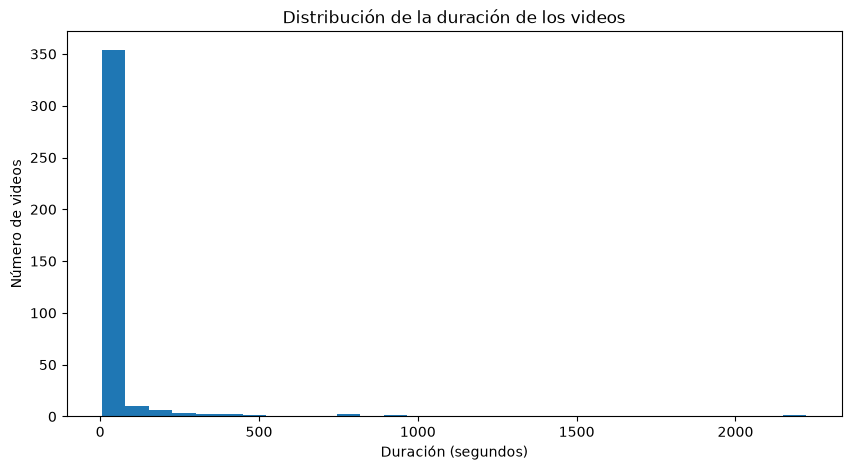

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["duracion_s"], bins=30)

plt.title("Distribución de la duración de los videos")
plt.xlabel("Duración (segundos)")
plt.ylabel("Número de videos")

plt.show()

In [ ]:
p95_duracion = df["duracion_s"].quantile(0.95)

print(f"Percentil 95 de duración: {p95_duracion:.2f} segundos")

Percentil 95 de duración: 121.72 segundos


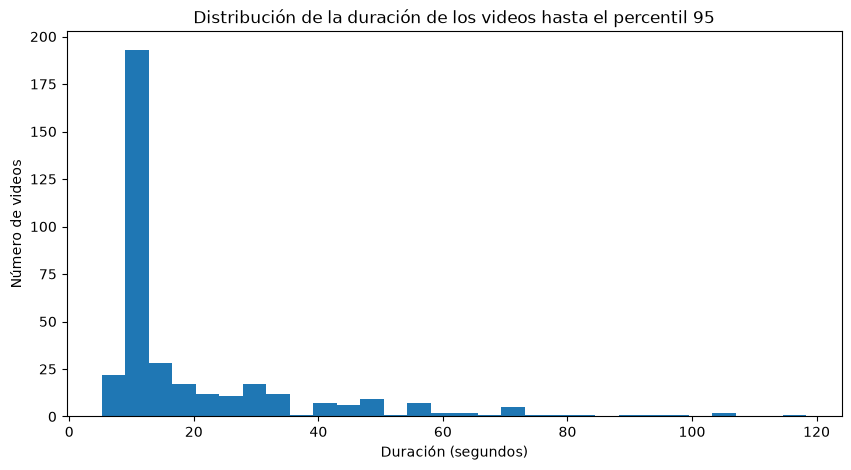

In [ ]:
duracion_hasta_p95 = df.loc[
    df["duracion_s"] <= p95_duracion,
    "duracion_s"
]

plt.figure(figsize=(10, 5))
plt.hist(duracion_hasta_p95, bins=30)

plt.title("Distribución de la duración de los videos hasta el percentil 95")
plt.xlabel("Duración (segundos)")
plt.ylabel("Número de videos")

plt.show()

#### Observaciones sobre la duración

La distribución de la duración presenta una asimetría positiva marcada. La mayor parte de los videos se concentra en duraciones cortas, principalmente alrededor de los primeros 10 a 15 segundos, mientras que un número reducido de muestras presenta duraciones considerablemente mayores.

El histograma del corpus completo muestra que algunos videos alcanzan duraciones superiores a varios cientos de segundos, con un máximo de 2223.27 segundos. Al limitar únicamente la visualización al percentil 95, correspondiente a 121.72 segundos, se observa con mayor claridad que la mayor parte de las muestras se encuentra concentrada en duraciones relativamente cortas.

El uso del percentil 95 en esta visualización no implica eliminar observaciones del análisis. Se utiliza únicamente para evitar que los videos extremadamente largos oculten la forma de la distribución principal.

/tmp/ipykernel_2334308/250132608.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


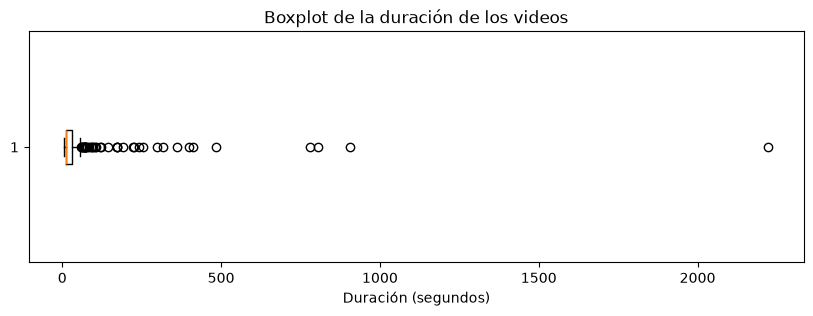

In [ ]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["duracion_s"],
    vert=False
)

plt.title("Boxplot de la duración de los videos")
plt.xlabel("Duración (segundos)")

plt.show()

#### Observaciones sobre valores extremos en la duración

El boxplot muestra una concentración importante de los videos en duraciones cortas y múltiples observaciones identificadas como posibles valores extremos bajo el criterio estándar del rango intercuartílico.

Estos valores no se consideran automáticamente errores. El análisis previo por fuente mostró que los videos de mayor duración se concentran principalmente en `Anomaly Detection Dataset UCF`, por lo que los valores extremos pueden corresponder a características propias de esa fuente y no necesariamente a problemas de calidad de datos.

Por esta razón, los valores extremos de duración se conservan en esta etapa del análisis y su tratamiento posterior dependerá de la estrategia de segmentación y construcción de clips para el modelado.

### Distribución de cuadros por segundo (FPS)

Se analiza la distribución de `fps` para identificar los valores predominantes y la variabilidad temporal entre los videos. Esta característica es relevante porque diferencias importantes en la frecuencia de cuadros pueden requerir una estrategia de estandarización antes del entrenamiento de los modelos.

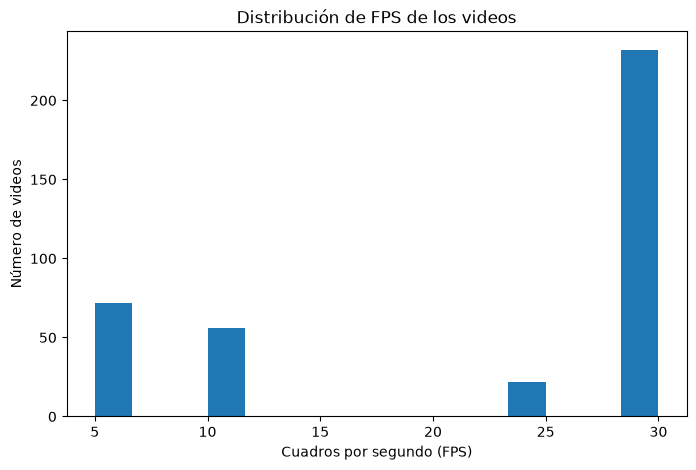

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["fps"], bins=15)

plt.title("Distribución de FPS de los videos")
plt.xlabel("Cuadros por segundo (FPS)")
plt.ylabel("Número de videos")

plt.show()

In [ ]:
frecuencia_fps = (
    df["fps"]
    .value_counts()
    .sort_index()
    .rename_axis("fps")
    .reset_index(name="cantidad")
)

frecuencia_fps["porcentaje"] = (
    frecuencia_fps["cantidad"] / len(df) * 100
).round(2)

frecuencia_fps

,fps,cantidad,porcentaje
0,5.0,72,18.85
1,10.0,56,14.66
2,24.0,22,5.76
3,30.0,232,60.73


#### Observaciones sobre la distribución de FPS

La distribución de cuadros por segundo se concentra en cuatro valores específicos: 5, 10, 24 y 30 FPS. El valor predominante es 30 FPS, presente en 232 videos (60.73% del corpus).

También se identifican 72 videos a 5 FPS (18.85%), 56 a 10 FPS (14.66%) y 22 a 24 FPS (5.76%). Esta distribución confirma que el corpus presenta distintas resoluciones temporales asociadas con las diferentes fuentes de video.

La heterogeneidad en FPS deberá considerarse durante la preparación de los datos, ya que los modelos de reconocimiento de acciones suelen requerir una estrategia consistente de muestreo temporal. No obstante, en esta etapa del EDA no se modifica la frecuencia original de los videos.

### Distribución de resoluciones espaciales

Se analiza la combinación de `ancho` y `alto` para identificar las resoluciones presentes en el corpus. Esta característica es relevante porque los modelos de video requieren posteriormente una estrategia consistente de redimensionamiento espacial.

In [ ]:
df["resolucion"] = (
    df["ancho"].astype(str)
    + "x"
    + df["alto"].astype(str)
)

frecuencia_resolucion = (
    df["resolucion"]
    .value_counts()
    .rename_axis("resolucion")
    .reset_index(name="cantidad")
)

frecuencia_resolucion["porcentaje"] = (
    frecuencia_resolucion["cantidad"] / len(df) * 100
).round(2)

frecuencia_resolucion

,resolucion,cantidad,porcentaje
0,640x480,302,79.06
1,320x240,50,13.09
2,1280x720,13,3.40
3,544x544,8,2.09
4,1920x1080,8,2.09
5,1366x768,1,0.26


#### Observaciones sobre la resolución espacial

La resolución predominante en el corpus es `640x480`, presente en 302 videos (79.06%). La segunda resolución más frecuente es `320x240`, con 50 videos (13.09%).

El resto de las resoluciones tiene una presencia considerablemente menor: `1280x720` representa el 3.40%, mientras que `544x544` y `1920x1080` representan cada una el 2.09%. También se identificó un único video con resolución `1366x768`.

Aunque existe heterogeneidad espacial entre las fuentes, la mayor parte del corpus se concentra en una resolución estándar de definición media. Esta característica deberá considerarse posteriormente al definir el redimensionamiento de los cuadros de entrada para los modelos de reconocimiento de acciones.

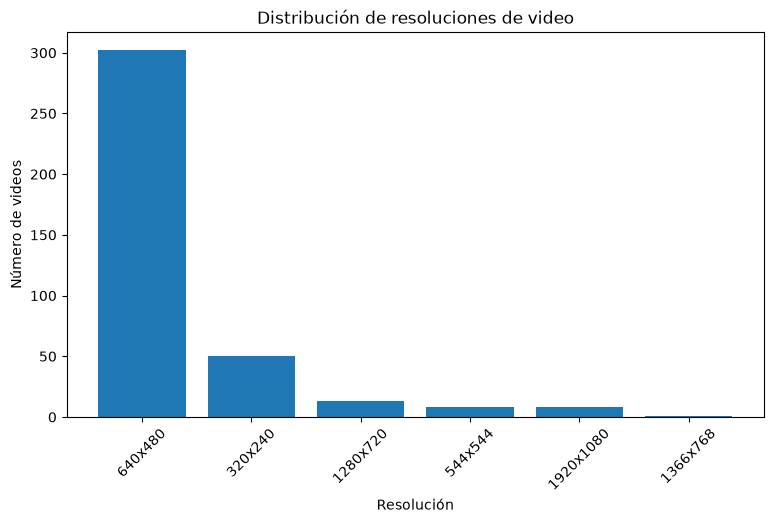

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    frecuencia_resolucion["resolucion"],
    frecuencia_resolucion["cantidad"]
)

plt.title("Distribución de resoluciones de video")
plt.xlabel("Resolución")
plt.ylabel("Número de videos")
plt.xticks(rotation=45)

plt.show()

## Análisis de diferencias entre fuentes

### Resolución espacial por fuente

Se analiza la distribución de resoluciones dentro de cada fuente para identificar si la heterogeneidad espacial del corpus está asociada con datasets específicos.

In [ ]:
resolucion_por_fuente = pd.crosstab(
    df["fuente"],
    df["resolucion"]
)

resolucion_por_fuente

resolucion,1280x720,1366x768,1920x1080,320x240,544x544,640x480
fuente,,,,,,
Anomaly Detection Dataset UCF,0,0,0,50,0,0
CCTV_Shoplifting_Dataset,0,0,0,0,8,0
MNNIT_h264,0,0,8,0,0,174
sintetico,13,1,0,0,0,0
venta_sospechosa,0,0,0,0,0,128


In [ ]:
resolucion_por_fuente_pct = (
    pd.crosstab(
        df["fuente"],
        df["resolucion"],
        normalize="index"
    ) * 100
).round(2)

resolucion_por_fuente_pct

resolucion,1280x720,1366x768,1920x1080,320x240,544x544,640x480
fuente,,,,,,
Anomaly Detection Dataset UCF,0.00,0.00,0.0,100.0,0.0,0.0
CCTV_Shoplifting_Dataset,0.00,0.00,0.0,0.0,100.0,0.0
MNNIT_h264,0.00,0.00,4.4,0.0,0.0,95.6
sintetico,92.86,7.14,0.0,0.0,0.0,0.0
venta_sospechosa,0.00,0.00,0.0,0.0,0.0,100.0


#### Observaciones sobre la resolución por fuente

La resolución espacial está fuertemente asociada con la fuente de procedencia. `Anomaly Detection Dataset UCF` utiliza exclusivamente resolución `320x240`, mientras que `CCTV_Shoplifting_Dataset` utiliza `544x544`. El conjunto `sintetico` se concentra principalmente en `1280x720`, con una muestra en `1366x768`.

`MNNIT_h264` utiliza principalmente resolución `640x480` (95.6%), aunque incluye una pequeña proporción de videos en `1920x1080`. Por su parte, `venta_sospechosa` utiliza exclusivamente `640x480`.

Estos resultados muestran que la resolución puede funcionar como una característica asociada a la fuente, pero no determina por sí misma la pertinencia de una muestra para el problema de estudio. En particular, distintas fuentes pueden compartir características técnicas similares aunque representar comportamientos diferentes.

### FPS por fuente

Se analiza la distribución de cuadros por segundo dentro de cada fuente para identificar si las diferencias de resolución temporal están asociadas con datasets específicos.

In [ ]:
fps_por_fuente = pd.crosstab(
    df["fuente"],
    df["fps"]
)

fps_por_fuente

fps,5.0,10.0,24.0,30.0
fuente,,,,
Anomaly Detection Dataset UCF,0,0,0,50
CCTV_Shoplifting_Dataset,0,0,8,0
MNNIT_h264,0,0,0,182
sintetico,0,0,14,0
venta_sospechosa,72,56,0,0


In [ ]:
fps_por_fuente_pct = (
    pd.crosstab(
        df["fuente"],
        df["fps"],
        normalize="index"
    ) * 100
).round(2)

fps_por_fuente_pct

fps,5.0,10.0,24.0,30.0
fuente,,,,
Anomaly Detection Dataset UCF,0.00,0.00,0.0,100.0
CCTV_Shoplifting_Dataset,0.00,0.00,100.0,0.0
MNNIT_h264,0.00,0.00,0.0,100.0
sintetico,0.00,0.00,100.0,0.0
venta_sospechosa,56.25,43.75,0.0,0.0


#### Observaciones sobre FPS por fuente

La distribución de cuadros por segundo está fuertemente asociada con la fuente de procedencia. `Anomaly Detection Dataset UCF` y `MNNIT_h264` utilizan exclusivamente 30 FPS, mientras que `CCTV_Shoplifting_Dataset` y el conjunto `sintetico` utilizan exclusivamente 24 FPS.

La fuente `venta_sospechosa` presenta un patrón temporal distinto al resto del corpus: el 56.25% de sus videos se encuentra a 5 FPS y el 43.75% a 10 FPS.

Esta diferencia indica que la fuente de procedencia puede estar asociada con características técnicas fácilmente identificables por un modelo. Si se combinaran las fuentes sin una estrategia adecuada de estandarización temporal, existe el riesgo de que el modelo aprenda patrones relacionados con el dataset de origen en lugar de concentrarse únicamente en la acción de interés.

No obstante, la diferencia de FPS no determina por sí misma la pertinencia de una fuente respecto al problema de estudio.

La decisión de inclusión o exclusión deberá considerar también el contenido semántico de los videos y su relación con la definición operacional del ocultamiento de mercancía.

### Duración por fuente

Se analiza la duración de los videos agrupada por fuente para identificar diferencias en la escala temporal de los distintos datasets y determinar si los valores extremos observados en el corpus se concentran en fuentes específicas.

<Figure size 1000x600 with 0 Axes>

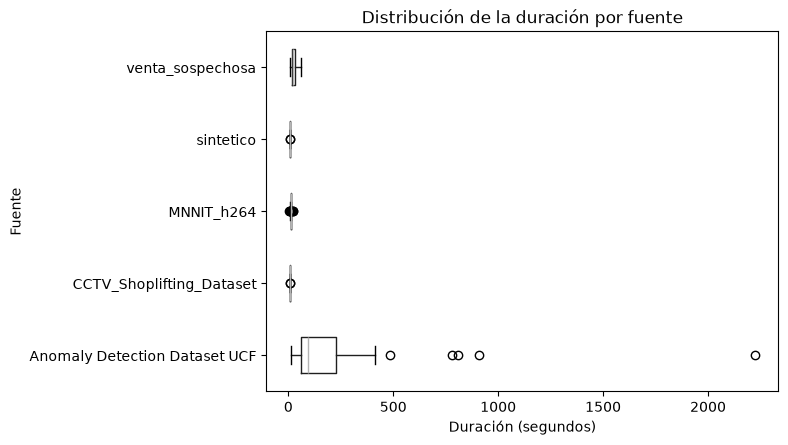

In [ ]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="duracion_s",
    by="fuente",
    vert=False,
    grid=False
)

plt.title("Distribución de la duración por fuente")
plt.suptitle("")
plt.xlabel("Duración (segundos)")
plt.ylabel("Fuente")

plt.show()

#### Observaciones sobre la duración por fuente

La duración de los videos presenta diferencias claras entre las fuentes.

`Anomaly Detection Dataset UCF` muestra la mayor variabilidad temporal y concentra los videos de mayor duración, incluyendo varios valores extremos que superan ampliamente la duración del resto del corpus.

En contraste, `MNNIT_h264`, `CCTV_Shoplifting_Dataset` y el conjunto `sintetico` se concentran principalmente en videos cortos. La fuente `venta_sospechosa` presenta duraciones mayores que estos conjuntos, pero con una dispersión considerablemente menor que UCF.

Estos resultados confirman que la fuente de procedencia está asociada con la escala temporal de los videos. Por tanto, la duración no debe interpretarse de forma aislada, ya que parte importante de su variabilidad responde a diferencias estructurales entre datasets.

### Correlación entre variables numéricas

Se analiza la correlación entre las principales variables cuantitativas del catálogo para identificar relaciones estructurales entre las características técnicas de los videos. Estas asociaciones se interpretan de manera exploratoria y no implican causalidad.

In [ ]:
variables_correlacion = [
    "fps",
    "duracion_s",
    "ancho",
    "alto",
    "frames"
]

matriz_correlacion = df[variables_correlacion].corr()

matriz_correlacion.round(2)

,fps,duracion_s,ancho,alto,frames
fps,1.00,0.09,-0.03,-0.09,0.16
duracion_s,0.09,1.00,-0.24,-0.33,1.00
ancho,-0.03,-0.24,1.00,0.96,-0.24
alto,-0.09,-0.33,0.96,1.00,-0.33
frames,0.16,1.00,-0.24,-0.33,1.00


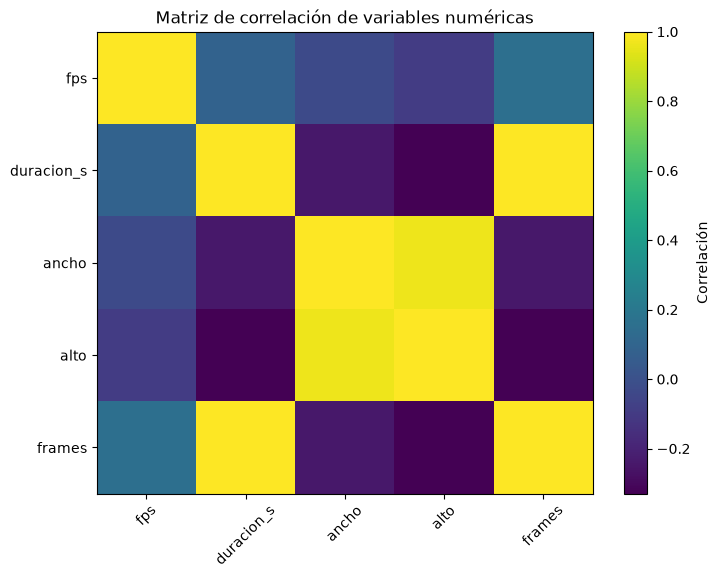

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    matriz_correlacion,
    aspect="auto"
)

plt.colorbar(label="Correlación")

plt.xticks(
    range(len(variables_correlacion)),
    variables_correlacion,
    rotation=45
)

plt.yticks(
    range(len(variables_correlacion)),
    variables_correlacion
)

plt.title("Matriz de correlación de variables numéricas")

plt.show()

#### Observaciones sobre la correlación entre variables numéricas

La matriz de correlación muestra una asociación prácticamente perfecta entre `duracion_s` y `frames`. Esta relación es esperable, ya que el número total de cuadros de un video depende de su duración y de la frecuencia de cuadros por segundo.

También se observa una correlación alta entre `ancho` y `alto` (`0.96`), consistente con el hecho de que las resoluciones de video suelen conservar proporciones espaciales definidas.

Las demás asociaciones son considerablemente menores. Se observan algunas correlaciones negativas moderadas entre duración y dimensiones espaciales, pero estas relaciones deben interpretarse con cautela, ya que el análisis previo mostró que las características técnicas están fuertemente asociadas con la fuente de procedencia.

Por tanto, las correlaciones observadas describen principalmente relaciones estructurales entre los metadatos del video y no implican relaciones causales entre las variables.

In [ ]:
print(f"Filas duplicadas completas: {df.duplicated().sum()}")
print(f"video_id duplicados: {df['video_id'].duplicated().sum()}")
print(f"archivo duplicados: {df['archivo'].duplicated().sum()}")

Filas duplicadas completas: 0
video_id duplicados: 0
archivo duplicados: 0


#### Observaciones sobre duplicados

No se identificaron filas duplicadas en el catálogo de metadatos. Tampoco se encontraron duplicados en `video_id` ni en `archivo`.

Esto indica que, dentro del inventario analizado, cada registro corresponde a una muestra única y no se detectaron repeticiones evidentes que pudieran alterar las frecuencias, estadísticas descriptivas o distribuciones calculadas.

In [ ]:
cardinalidad = pd.DataFrame({
    "variable": [
        "fuente",
        "clase",
        "estado_muestra",
        "resolucion"
    ],
    "categorias_unicas": [
        df["fuente"].nunique(),
        df["clase"].nunique(),
        df["estado_muestra"].nunique(),
        df["resolucion"].nunique()
    ]
})

cardinalidad

,variable,categorias_unicas
0,fuente,5
1,clase,3
2,estado_muestra,2
3,resolucion,6


#### Observaciones sobre cardinalidad

Las variables categóricas analizadas presentan una cardinalidad baja. `fuente` contiene 5 categorías, `clase` 3, `estado_muestra` 2 y `resolucion` 6.

Por tanto, no se identifican problemas de alta cardinalidad en estas variables y no es necesario agrupar o reducir categorías durante esta etapa del análisis exploratorio.

Las categorías se conservan con su significado original, ya que representan información relevante sobre la procedencia, estado y características técnicas de los videos.

## Decisiones de preprocesamiento derivadas del EDA

A partir de los resultados del análisis exploratorio, en esta etapa no se aplican transformaciones sobre los videos originales. Las decisiones actuales son las siguientes:

- **Valores faltantes:** no se requiere imputación en las variables técnicas principales (`fps`, `duracion_s`, `ancho`, `alto` y `frames`), ya que se encuentran completas para los 382 videos. Los valores vacíos de `motivo_exclusion` corresponden al estado actual del proceso y no representan datos faltantes que deban imputarse.

- **Valores atípicos:** los videos con duraciones extremas se conservan. El análisis mostró que estos valores se concentran principalmente en una fuente específica y no existe evidencia de que correspondan a archivos inválidos.

- **Duplicados:** no se detectaron filas duplicadas, `video_id` repetidos ni nombres de archivo duplicados en el catálogo analizado, por lo que no se requiere eliminación de registros por este motivo.

- **Variables categóricas:** las variables `fuente`, `clase`, `estado_muestra` y `resolucion` presentan baja cardinalidad, por lo que no se requiere agrupación o reducción de categorías en esta etapa.

- **Balance de clases:** no se realiza remuestreo. El equilibrio observado entre `ocultamiento` y `sin_ocultamiento` corresponde únicamente a `MNNIT_h264`, mientras que las demás fuentes permanecen pendientes de revisión.

- **FPS y resolución:** no se modifican durante el EDA. La estandarización temporal y espacial se definirá posteriormente durante la preparación de clips para experimentación.

- **Normalización de imágenes:** se pospone hasta definir con precisión las representaciones de entrada y los modelos que se utilizarán.

- **Segmentación temporal:** no se realiza en este avance. La construcción de clips o ventanas temporales se llevará a cabo en la etapa de preparación de datos, manteniendo separados los segmentos derivados de un mismo video para evitar fuga de información.

## Síntesis del análisis exploratorio

### Hallazgos principales

El análisis exploratorio se realizó sobre un corpus inicial de 382 videos provenientes de cinco fuentes diferentes. La caracterización muestra que el conjunto es heterogéneo tanto en su composición como en sus características técnicas.

`MNNIT_h264` representa el 47.64% de los videos y `venta_sospechosa` el 33.51%, por lo que ambas fuentes concentran más del 80% del corpus. Las demás fuentes tienen una representación considerablemente menor.

La duración presenta una distribución fuertemente asimétrica. La mediana global es de 11.70 segundos, mientras que algunos videos alcanzan duraciones superiores a varios cientos de segundos y un máximo de 2223.27 segundos. El análisis por fuente mostró que estos valores extremos se concentran principalmente en `Anomaly Detection Dataset UCF`.

La frecuencia temporal se concentra en cuatro valores: 5, 10, 24 y 30 FPS. El 60.73% de los videos se encuentra a 30 FPS, aunque existen diferencias claras entre fuentes. `Anomaly Detection Dataset UCF` y `MNNIT_h264` utilizan 30 FPS, `CCTV_Shoplifting_Dataset` y el conjunto `sintetico` utilizan 24 FPS, mientras que `venta_sospechosa` contiene videos a 5 y 10 FPS.

La resolución espacial predominante es `640x480`, presente en el 79.06% del corpus. Sin embargo, también existen resoluciones desde `320x240` hasta `1920x1080`. La resolución está asociada con la fuente de procedencia, lo que confirma que los datasets presentan perfiles técnicos diferentes.

De los 382 videos, 182 cuentan actualmente con una etiqueta asociada con las clases objetivo: 92 como `ocultamiento` y 90 como `sin_ocultamiento`. Estas muestras pertenecen exclusivamente a `MNNIT_h264`. Los 200 videos restantes permanecen pendientes de revisión, por lo que el equilibrio observado entre las clases no puede interpretarse todavía como representativo del corpus completo.

No se identificaron valores faltantes ni valores técnicamente inválidos en los metadatos básicos de los videos. Tampoco se encontraron filas duplicadas, identificadores repetidos ni nombres de archivo duplicados. Las variables categóricas analizadas presentan baja cardinalidad, por lo que no requieren agrupación o reducción de categorías en esta etapa.

El análisis de correlación muestra una asociación prácticamente perfecta entre `duracion_s` y `frames`, así como una correlación alta entre `ancho` y `alto`. Estas relaciones son consistentes con la estructura técnica de los archivos de video y no deben interpretarse como relaciones causales.

En conjunto, el EDA muestra que la fuente de procedencia está asociada con diferencias de duración, FPS y resolución. Esta heterogeneidad introduce un riesgo de sesgo por fuente, ya que un modelo podría aprender características propias del dataset de origen en lugar de patrones relacionados con la acción de interés. Por ello, la procedencia de las muestras deberá considerarse en la preparación de clips, la definición de particiones y la evaluación de los modelos en las siguientes etapas.

### Limitaciones del EDA actual

El análisis realizado se concentra principalmente en características técnicas y estructurales a nivel de video completo. Por tanto, todavía no permite caracterizar con detalle la ubicación temporal de los eventos de ocultamiento dentro de cada video.

Actualmente, solo `MNNIT_h264` cuenta con etiquetas directamente asociadas con las clases objetivo del proyecto. Las demás fuentes requieren una revisión adicional para determinar su pertinencia respecto a la definición operacional de `ocultamiento` y `sin_ocultamiento`. Esta revisión podrá modificar posteriormente la composición del conjunto candidato para modelado.

Tampoco se dispone todavía, para todo el corpus, de anotaciones homogéneas sobre variables como número de sujetos, tipo de escena, visibilidad del producto, presencia de oclusiones o duración específica del evento de ocultamiento.

Estas limitaciones impiden realizar en esta etapa un análisis completo de la distribución de eventos a nivel temporal. No obstante, no afectan la caracterización estructural del corpus ni el análisis de diferencias técnicas entre fuentes realizado en este notebook.

Adicionalmente, el dataset `RetailS`, considerado para los experimentos basados en pose, no se incorpora a las estadísticas del corpus RGB debido a que utiliza una representación y una unidad de análisis diferentes. Su caracterización se realizará de forma independiente durante la preparación de las secuencias de pose.

La preparación de un manifiesto a nivel de clip/evento se encuentra en desarrollo y permitirá complementar posteriormente este análisis con información temporal y semántica más detallada.

### Trabajo pendiente y relación con el Avance 2

A partir de los hallazgos del análisis exploratorio, el siguiente paso será preparar las distintas representaciones de datos que se utilizarán para el reconocimiento temporal de acciones.

Además del corpus de videos RGB analizado en este notebook, el proyecto contempla evaluar una representación alternativa basada en estimación de pose mediante el dataset RetailS. Este conjunto no se integró directamente en el presente análisis exploratorio debido a que su estructura es diferente: en lugar de representar cada muestra como un archivo de video, contiene información asociada con personas, cuadros y puntos corporales mediante coordenadas y valores de confianza.

Por esta razón, RetailS será caracterizado de manera independiente antes de construir las secuencias temporales de pose que se utilizarán en los experimentos correspondientes. La comparación entre ambas representaciones se realizará posteriormente a nivel de modelos y resultados experimentales, evitando combinar en una misma estructura datos RGB y datos de pose con unidades de análisis diferentes.

El equipo se encuentra trabajando en la construcción de un manifiesto a nivel de clip/evento, que permitirá registrar información temporal y semántica más detallada para cada muestra. Esta estructura se utilizará posteriormente para segmentar los videos, definir ventanas de análisis y preparar los datos para entrenamiento y evaluación.

Entre las actividades pendientes se encuentran:

- revisar la pertinencia semántica de las fuentes que todavía permanecen como `pendiente_revision`;
- definir, cuando sea posible, el inicio y fin de los eventos de interés;
- generar clips o ventanas temporales a partir de los videos originales;
- homologar criterios de etiquetado entre las distintas fuentes;
- documentar y justificar posibles decisiones de inclusión o exclusión a partir de la pertinencia respecto al problema de estudio;
- definir una estrategia de estandarización temporal y espacial para FPS y resolución;
- definir las particiones de entrenamiento, validación y prueba manteniendo juntos los clips derivados de un mismo video u origen, con el propósito de reducir el riesgo de fuga de información;
- caracterizar RetailS y preparar de manera independiente las secuencias que se utilizarán en los experimentos basados en pose.

Estas actividades corresponden principalmente a la etapa de preparación, segmentación, etiquetado y preprocesamiento de los datos, y se desarrollarán como parte del Avance 2.

Por tanto, el resultado de este Avance 1 es una caracterización inicial del corpus RGB que permite identificar su composición, heterogeneidad técnica, estado de etiquetado y principales riesgos de preparación antes de construir las muestras que serán utilizadas en los experimentos. De manera complementaria, se reconoce la existencia de una segunda representación basada en pose que será analizada y preparada por separado.